In [1]:
import os
import random
import numpy as np
from ase.io import read
from quests.descriptor import get_descriptors
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from adjustText import adjust_text
from scipy.spatial.distance import pdist
import matplotlib
from matplotlib.colors import Normalize, LinearSegmentedColormap, ListedColormap, BoundaryNorm
from matplotlib.cm import ScalarMappable
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
# from before, copied code
dH = np.load('/data/christine/quests/mptrj/mptrj_subset_dH.npy')
dH[np.isinf(dH)] = 0
dH.shape

subset_indices = np.load("/data/christine/quests/mptrj/mptrj_subset_descriptor_indices.npy")

# using sum of each structure's descriptors' entropy
# Compute sum per index
sum_entropy_per_index = np.bincount(subset_indices, weights=dH)

# Compute counts per index
counts = np.bincount(subset_indices)

# Avoid division by zero
avg_entropies = np.divide(sum_entropy_per_index, counts, where=counts > 0)

avg_entropies.shape

(5318,)

In [3]:
# get a subset of mptrj
random.seed(88)

def random_sample_from_directory(directory, sample_size):
    files = sorted(os.listdir(directory))  # Get all files
    files = [f for f in files if os.path.isfile(os.path.join(directory, f))]  # Filter only files
    sample = random.sample(files, min(sample_size, len(files)))  # Pick random sample
    return sample

data_dir = "/data/shared/MPTrj/original"
sample_size = 500

random_files = random_sample_from_directory(data_dir, sample_size)

num_structures_per_file = []
for file in random_files:
    atoms = read(os.path.join(data_dir, file), index=":")
    num_structures_per_file.append(len(atoms))

sum(num_structures_per_file)

5318

In [4]:
# now, extract the items from avg_entropies that correspond to the last structure per file
last_entropies = []
curr_index = 0
for item in num_structures_per_file:
    curr_index += item
    last_entropies.append(avg_entropies[curr_index-1])

print(curr_index)  # should be 5318
len(last_entropies)

5318


500

In [5]:
# we only ran simulations on every 10th of these, and we also excluded structures 4, 9, and 41 for having too many atoms
sim_entropies = last_entropies[::10]
sim_entropies = np.delete(sim_entropies, [4, 9, 41])

# append the 100 new structures we ran simulations on
new_structures = []
for i, item in enumerate(last_entropies):
    if i % 10 == 1 or i % 10 == 2:
        new_structures.append(item)
        
# excluding the structures that have too many atoms
new_structures = np.delete(new_structures, [0, 32, 78, 93])
        
sim_entropies = np.append(sim_entropies, new_structures)
len(sim_entropies)

143

In [6]:
# check the trajectories to see whether they are stable for each model
max_distance = 2
min_distance = 0.7
sim_dirs = ['/home/christine/mlip-arena/simulations/mptrj', '/home/christine/mlip-arena/simulations_100/mptrj']
sim_folders = sorted(os.listdir(sim_dirs[0]))  # they should have the same folder names
in_thresh = {folder: [] for folder in sim_folders}
out_thresh = {folder: [] for folder in sim_folders}
for sim_dir in sim_dirs:
    for folder in sim_folders:
        if "DeepMD" in folder:
            continue
        for traj_file in sorted(os.listdir(os.path.join(sim_dir, folder))):
            is_out_thresh = False
            traj = read(os.path.join(sim_dir, folder, traj_file), index=':')
            
            # max distance between atoms at the beginning and end
            val_i = np.max(pdist(traj[0].get_positions()))
            val_f = np.max(pdist(traj[-1].get_positions()))
            diff = abs(val_i - val_f)
            if diff > max_distance:
                out_thresh[folder].append(traj_file)
                is_out_thresh = True
                
            # check if atoms too close together. note: might have to check all frames
            distances = pdist(traj[-1].get_positions())  # all pairwise distances
            if np.any(distances < min_distance):
                out_thresh[folder].append(traj_file)
                is_out_thresh = True
                
            if not is_out_thresh:
                in_thresh[folder].append(traj_file)
            
        print(f"done with {folder}")

done with CHGNet_MPTrj_sims_supercell_1000K
done with MACE-MP(M)_MPTrj_sims_supercell_1000K
done with MACE-MPA_MPTrj_sims_supercell_1000K
done with MatterSim_MPTrj_sims_supercell_1000K
done with ORBv2_MPTrj_sims_supercell_1000K
done with SevenNet_MPTrj_sims_supercell_1000K
done with eqV2(OMat)_MPTrj_sims_supercell_1000K
done with CHGNet_MPTrj_sims_supercell_1000K
done with MACE-MP(M)_MPTrj_sims_supercell_1000K
done with MACE-MPA_MPTrj_sims_supercell_1000K
done with MatterSim_MPTrj_sims_supercell_1000K
done with ORBv2_MPTrj_sims_supercell_1000K
done with SevenNet_MPTrj_sims_supercell_1000K
done with eqV2(OMat)_MPTrj_sims_supercell_1000K


In [7]:
print("IN THRESH")
for key, value in in_thresh.items():
    print(f"{key}: {len(value)}")
print("\nOUT THRESH")
for key, value in out_thresh.items():
    print(f"{key}: {len(value)}")

IN THRESH
CHGNet_MPTrj_sims_supercell_1000K: 116
DeepMD_MPTrj_sims_supercell_1000K: 0
MACE-MP(M)_MPTrj_sims_supercell_1000K: 120
MACE-MPA_MPTrj_sims_supercell_1000K: 124
MatterSim_MPTrj_sims_supercell_1000K: 121
ORBv2_MPTrj_sims_supercell_1000K: 115
SevenNet_MPTrj_sims_supercell_1000K: 122
eqV2(OMat)_MPTrj_sims_supercell_1000K: 122

OUT THRESH
CHGNet_MPTrj_sims_supercell_1000K: 28
DeepMD_MPTrj_sims_supercell_1000K: 0
MACE-MP(M)_MPTrj_sims_supercell_1000K: 23
MACE-MPA_MPTrj_sims_supercell_1000K: 20
MatterSim_MPTrj_sims_supercell_1000K: 22
ORBv2_MPTrj_sims_supercell_1000K: 29
SevenNet_MPTrj_sims_supercell_1000K: 21
eqV2(OMat)_MPTrj_sims_supercell_1000K: 21


In [8]:
# sim_entropies will be the x-axis for the simulation scatter plots. now we need to get the energy conservation values
model_names = [
    "MACE-MP(M)", "CHGNet", "MatterSim", "ORBv2", "SevenNet", "MACE-MPA", "eqV2(OMat)"]
#     "eqV2(OMat)", "DeepMD", "ORB"

energy_cons = {model_name: [] for model_name in model_names}
entropies = {model_name: sim_entropies[:] for model_name in model_names}

sim_dirs = ['/home/christine/mlip-arena/simulations/mptrj', '/home/christine/mlip-arena/simulations_100/mptrj']
for sim_dir_num, sim_dir in enumerate(sim_dirs):
    for model_name in model_names:
        dir_name = f"{sim_dir}/{model_name}_MPTrj_sims_supercell_1000K"
        for i, file in enumerate(sorted(os.listdir(dir_name))):
            # check to make sure they are stable
            if sim_dir_num == 1:
                num = i + 47
            else:
                num = i
            if file not in in_thresh[f'{model_name}_MPTrj_sims_supercell_1000K'] or np.isnan(entropies[model_name][num]):
                entropies[model_name][num] = np.nan # set entropy to nan, and remove the nan elements later so we don't get indexing errors in the loop

In [9]:
idxs_to_remove = {}
for model_name in model_names:
    idxs_to_remove[model_name] = np.where(np.isnan(entropies[model_name]))[0]
idxs_to_remove

{'MACE-MP(M)': array([  2,  10,  16,  23,  25,  33,  34,  37,  45,  48,  50,  52,  56,
         58,  61,  67,  73,  78,  82,  84,  87,  88,  89,  95,  96,  97,
         99, 106, 107, 108, 112, 123, 126, 128, 131, 137]),
 'CHGNet': array([  2,  10,  16,  23,  25,  33,  34,  37,  45,  48,  50,  52,  56,
         58,  61,  67,  73,  78,  82,  84,  87,  88,  89,  95,  96,  97,
         99, 106, 107, 108, 112, 123, 126, 128, 131, 137]),
 'MatterSim': array([  2,  10,  16,  23,  25,  33,  34,  37,  45,  48,  50,  52,  56,
         58,  61,  67,  73,  78,  82,  84,  87,  88,  89,  95,  96,  97,
         99, 106, 107, 108, 112, 123, 126, 128, 131, 137]),
 'ORBv2': array([  2,  10,  16,  23,  25,  33,  34,  37,  45,  48,  50,  52,  56,
         58,  61,  67,  73,  78,  82,  84,  87,  88,  89,  95,  96,  97,
         99, 106, 107, 108, 112, 123, 126, 128, 131, 137]),
 'SevenNet': array([  2,  10,  16,  23,  25,  33,  34,  37,  45,  48,  50,  52,  56,
         58,  61,  67,  73,  78,  82,  84,  8

In [10]:
# to get which descriptors correspond to which structure
k, cutoff = 32, 5.0
model_name = 'CHGNet'
structures = []
desc_to_structure = []
folder = f'{model_name}_MPTrj_sims_supercell_1000K'
for sim_dir in sim_dirs:
    for i, traj_file in enumerate(sorted(os.listdir(os.path.join(sim_dir, folder)))):
        traj = read(os.path.join(sim_dir, folder, traj_file), index=':')
        every_other = traj[2:49:2]
        structures.extend(every_other)
        
for i, structure in enumerate(structures):
    y = get_descriptors([structure], k=k, cutoff=cutoff)
    desc_to_structure.extend([i] * len(y))

In [11]:
# merge bins together
def merge_bins(arr, n):
    num_full = len(arr) // n
    rem = len(arr) % n

    # Average full groups
    averaged = arr[:num_full * n].reshape(-1, n).mean(axis=1)

    # Handle the remainder
    if rem:
        last_avg = arr[-rem:].mean()
        averaged = np.append(averaged, last_avg)
        
    return averaged

In [12]:
def merge_bins_2d(data, n):
    """
    Bin 2D data of shape (samples, time) by averaging every n time points.
    """
    num_full = data.shape[1] // n
    rem = data.shape[1] % n

    # Bin full groups
    binned = data[:, :num_full * n].reshape(data.shape[0], -1, n).mean(axis=2)

    # Handle remainder
    if rem:
        remainder = data[:, -rem:].mean(axis=1, keepdims=True)
        binned = np.concatenate((binned, remainder), axis=1)

    return binned

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

MACE-MP(M)
(107, 23)
(107, 23)
CHGNet
(107, 23)
(107, 23)
MatterSim
(107, 23)
(107, 23)
ORBv2
(107, 23)
(107, 23)
SevenNet
(107, 23)
(107, 23)
MACE-MPA
(107, 23)
(107, 23)
eqV2(OMat)
(107, 23)
(107, 23)


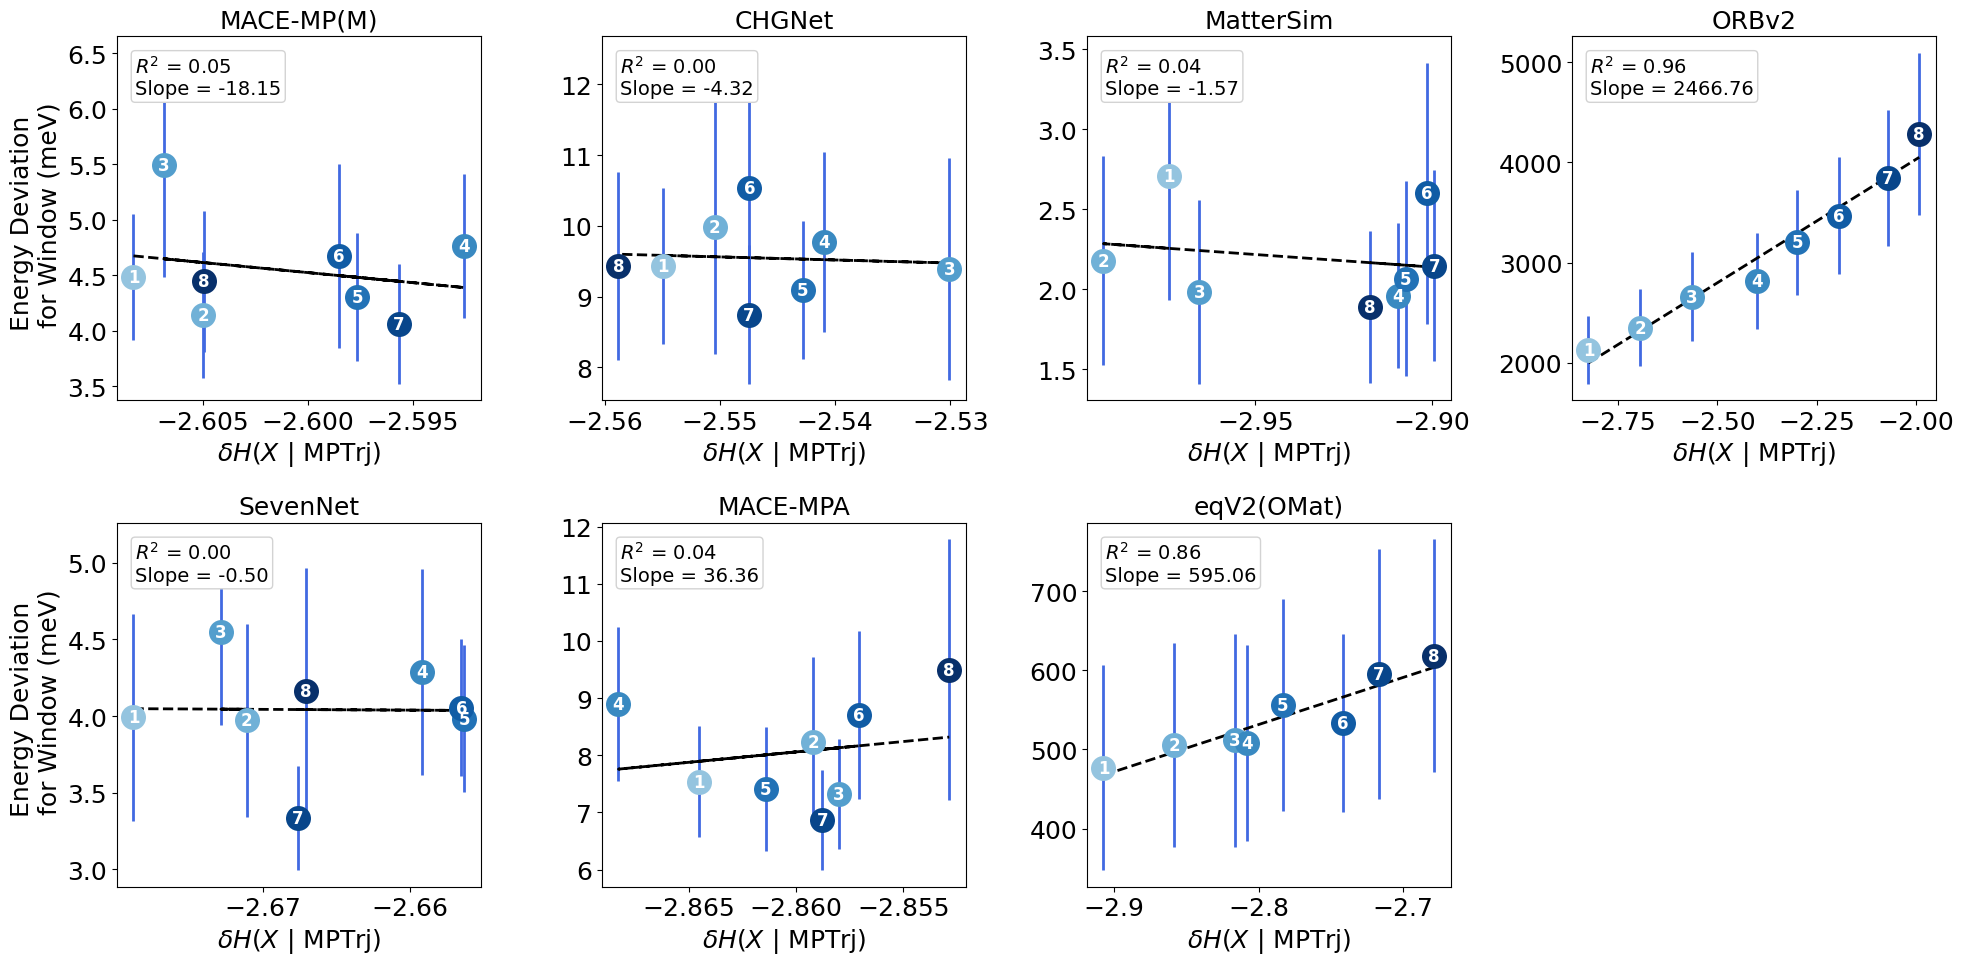

In [13]:
# Increase all font sizes
matplotlib.rcParams.update({'font.size': 18})
cmap = plt.get_cmap("Blues")

# all in one cell
sim_dirs = ['/data/christine/mlip-arena/simulations/mptrj', '/data/christine/mlip-arena/simulations_100/mptrj']
model_names = ["MACE-MP(M)", "CHGNet", "MatterSim", "ORBv2", "SevenNet", "MACE-MPA", "eqV2(OMat)",] #"SevenNet",]
entropy_along_trajectory = np.array([])
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for model_num, model_name in enumerate(model_names):
    structures = []
    window_energy_cons = []
    folder = f'{model_name}_MPTrj_sims_supercell_1000K'
    print(model_name)
    
    # load the entropies along trajectories, which are different for each sim_dir and model
    entropy_along_trajectory = np.array([])
    entropy_along_trajectory = np.append(entropy_along_trajectory, np.load(f'/data/christine/mlip-arena/trajectory_dH/mptrj_traj_{model_name}_MPTrj_sims_supercell_1000K_dH.npy', allow_pickle=True))
    entropy_along_trajectory = np.append(entropy_along_trajectory, np.load(f'/data/christine/mlip-arena/trajectory_dH/mptrj_traj_{model_name}_100_dH.npy', allow_pickle=True))
    
    for sim_dir in sim_dirs:
        for i, traj_file in enumerate(sorted(os.listdir(os.path.join(sim_dir, folder)))):
            traj = read(os.path.join(sim_dir, folder, traj_file), index=':')
            every_other = traj[2:49:2]  # this is the middle of the windows
            structures.extend(every_other)
                
        for i, traj_file in enumerate(sorted(os.listdir(os.path.join(sim_dir, folder)))):
            traj = read(os.path.join(sim_dir, folder, traj_file), index=':')
            initials = traj[:48:2]
            finals = traj[4::2]
            try:
                energy_dev = [abs(initial.get_total_energy() - final.get_total_energy()) * 1000 for initial, final in zip(initials, finals)]
            except:
                # this is bad but if there's an error, this one should be removed anyway, so pad with junk
                energy_dev = [np.nan] * len(initials)
            window_energy_cons.extend(energy_dev)
        
    # using sum of each structure's descriptors' entropy
    # Compute sum per index
    subset_indices = np.array(desc_to_structure)
    sum_entropy_per_index = np.bincount(subset_indices, weights=entropy_along_trajectory)
    counts = np.bincount(subset_indices)
    avg_entropies = np.divide(sum_entropy_per_index, counts, where=counts > 0)
    ax = axes[model_num]
    
    # Get indices to include (which trajectories are good/stable)
    valid_indices = [i for i in range(143) if i not in idxs_to_remove[model_name]]
    
    x = np.array(avg_entropies).reshape(143, 24)
    y = np.array(window_energy_cons).reshape(143, 24)
    # Stack only valid entries (shape: (num_valid, 24))
    x_valid = x[valid_indices]  # shape: (num_valid, 24)
    y_valid = y[valid_indices]  # shape: (num_valid, 24)
    
    # get rid of the first frame for each trajectory
    x_valid = x_valid[:, 1:]
    y_valid = y_valid[:, 1:]
    
    n_valid = x_valid.shape[0]
    print(x_valid.shape)
    print(y_valid.shape)
    
    # Bin raw data first
    bin_size = 3
    x_binned = merge_bins_2d(x_valid, bin_size)  # shape: (n_valid, 8)
    y_binned = merge_bins_2d(y_valid, bin_size)
    # Compute mean and 95% CI across trajectories
    avg_x = x_binned.mean(axis=0)  # shape: (23,) since we got rid of the first frame, or else it would be 24
    avg_y = y_binned.mean(axis=0)
    stderr_x = 1.96 * x_binned.std(axis=0, ddof=1) / np.sqrt(n_valid * bin_size)
    stderr_y = 1.96 * y_binned.std(axis=0, ddof=1) / np.sqrt(n_valid * bin_size)
    
    # color code by number
    # Plot each point individually with corresponding color
    for j in range(len(avg_x)):
        color_val = 0.4 + 0.6 * (j / (len(avg_x) - 1))
        color = cmap(color_val)
        ax.errorbar(
            avg_x[j],
            avg_y[j],
            yerr=stderr_y[j],
            fmt='o',
            ecolor='royalblue',
            elinewidth=2,
            capsize=3, # the caps don't work
            markersize=18,
            markerfacecolor=color,
            markeredgewidth=0
        )
        ax.annotate(str(j+1), (avg_x[j], avg_y[j]), fontsize=12, color='white',
                    ha='center', va='center', fontweight='bold')
        
    # Line of best fit with r^2
    slope, intercept = np.polyfit(avg_x, avg_y, 1)
    line = slope * avg_x + intercept
    ax.plot(avg_x, line, color='black', linestyle='--', linewidth=2)
    # Calculate Pearson r and R^2
    r, p = pearsonr(avg_x, avg_y)
    r_squared = r**2
    ax.text(
        0.05, 0.95,
        f"$R^2$ = {r_squared:.2f}\nSlope = {slope:.2f}",
        transform=ax.transAxes,
        fontsize=14,
        verticalalignment='top',
        color='black',
        bbox=dict(facecolor='white', edgecolor='lightgray', boxstyle='round,pad=0.2')
    )
       
    ax.set_xlabel(r"$\delta H (X\ |\ \mathrm{MPTrj})$", fontsize=18)
    if model_num == 0 or model_num == 4:
        ax.set_ylabel("Energy Deviation \n for Window (meV)", fontsize=18)
    ax.set_title(f"{model_name}", fontsize=18)
    
axes[7].axis('off')

plt.tight_layout()
plt.savefig("eng_dh.png", bbox_inches="tight")
plt.savefig("eng_dh.pdf", bbox_inches="tight")
plt.show()

In [14]:
# 1d version? not sure if this is correct
# bin_size = 3
# avg_x = merge_bins(avg_x, bin_size)
# avg_y = merge_bins(avg_y, bin_size)

# # Compute standard deviation across trajectories (axis=0)
# n_valid = x_valid.shape[0]  # should be 143 - len(idxs_to_remove[model_name])
# stderr_x = 1.96 * np.std(x_valid, axis=0) / np.sqrt(n_valid)  # 95% confidence interval
# stderr_y = 1.96 * np.std(y_valid, axis=0) / np.sqrt(n_valid)
# stderr_x = merge_bins(stderr_x, 3)
# stderr_y = merge_bins(stderr_y, 3)

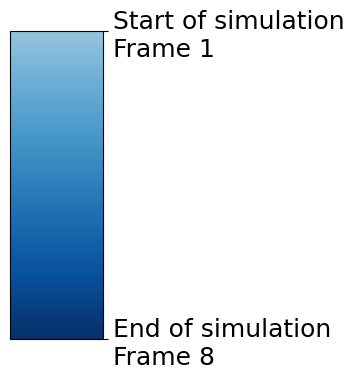

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# Get the desired slice of the colormap
matplotlib.rcParams.update({'font.size': 18})
base_cmap = plt.get_cmap('Blues')
colors = base_cmap(np.linspace(0.4, 1.0, 256))  # 256 for smooth gradient
custom_cmap = mpl.colors.ListedColormap(colors)

# Normalize to frame numbers 1 to 8
norm = mpl.colors.Normalize(vmin=1, vmax=8)

# Create a scalar mappable for the colorbar
sm = mpl.cm.ScalarMappable(norm=norm, cmap=custom_cmap)
sm.set_array([])  # Required for plt.colorbar

# Create a new figure for just the colorbar
fig, ax = plt.subplots(figsize=(1.2, 4))
cb = plt.colorbar(sm, cax=ax)

cb.ax.invert_yaxis()

# Add two-line tick labels
cb.set_ticks([1, 8])
cb.set_ticklabels(['Start of simulation\nFrame 1', 'End of simulation\nFrame 8'])

plt.savefig('colorbar_gradient_fixed.png', bbox_inches='tight')
plt.show()


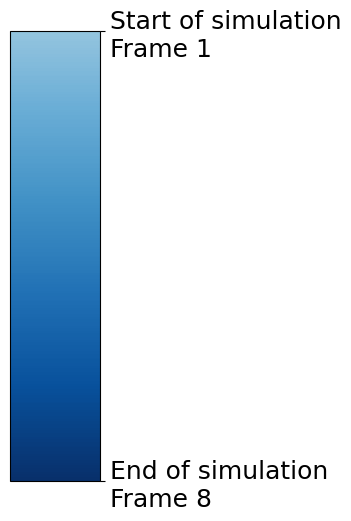

In [22]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# Customize font and colormap
mpl.rcParams.update({'font.size': 18})
base_cmap = plt.get_cmap('Blues')
colors = base_cmap(np.linspace(0.4, 1.0, 256))  # 256 for smooth gradient
custom_cmap = mpl.colors.ListedColormap(colors)

# Normalize from frame 1 to 8
norm = mpl.colors.Normalize(vmin=1, vmax=8)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=custom_cmap)
sm.set_array([])

# Create a tall and narrow figure
fig = plt.figure(figsize=(3, 5))  # adjust height here to match your subplot height
ax = fig.add_axes([0.3, 0.05, 0.3, 0.9])  # [left, bottom, width, height]

cb = plt.colorbar(sm, cax=ax)
cb.ax.invert_yaxis()
cb.set_ticks([1, 8])
cb.set_ticklabels(['Start of simulation\nFrame 1', 'End of simulation\nFrame 8'])

plt.savefig('colorbar_gradient_tall.png', bbox_inches='tight', dpi=300)
plt.show()
